In [2]:
import pandas as pd

In [3]:
clean_data = pd.read_pickle(r"O:\Project\NutriScore\Data\clean_data.pkl")
clean_data.reset_index(inplace=True)
clean_data.drop(columns=["index","score","sodium"], inplace = True)
 
clean_data

,grade,group1,group2,energy,saturated_fat,sugars,salt,fibers,proteins
0,unknown,unknown,unknown,690.0,2.00,12.6,NaN,3.0,1.5
1,a,Milk and dairy products,Biscuits and cakes,238.0,0.10,3.9,0.09,NaN,10.0
2,unknown,unknown,unknown,1569.0,3.08,15.0,1.40,NaN,7.8
3,unknown,unknown,unknown,685.8,1.00,NaN,1.10,NaN,15.3
4,unknown,unknown,unknown,3661.0,6.10,1.0,2.10,NaN,15.7
...,...,...,...,...,...,...,...,...,...
2305661,a,Fish Meat Eggs,Meat,548.0,2.30,0.0,0.18,NaN,21.5
2305662,unknown,unknown,unknown,418.0,1.00,1.0,1.00,NaN,1.0
2305663,unknown,unknown,unknown,2489.0,6.40,0.0,0.40,8.5,29.8
2305664,unknown,unknown,unknown,100.0,0.00,0.6,0.64,NaN,1.6


In [4]:
clean_data.drop(columns=['group2'], inplace = True)
clean_data = clean_data.dropna()

clean_data

,grade,group1,energy,saturated_fat,sugars,salt,fibers,proteins
5,unknown,unknown,0.0,0.0,0.00,0.000,0.0,0.0
6,d,Fat and sauces,936.0,2.2,22.00,4.600,0.0,5.1
9,d,Beverages,264.0,0.0,15.50,0.000,0.0,0.2
16,unknown,unknown,916.0,0.5,1.70,0.464,2.8,9.7
17,d,Composite foods,1594.0,15.5,21.90,0.100,4.4,4.6
...,...,...,...,...,...,...,...,...
2305646,unknown,unknown,1661.0,0.0,73.00,0.000,1.0,0.1
2305648,a,Milk and dairy products,150.0,0.1,5.00,0.120,0.0,3.6
2305650,unknown,unknown,1552.0,2.5,0.58,0.380,2.0,1.0
2305663,unknown,unknown,2489.0,6.4,0.00,0.400,8.5,29.8


####  convert our qualitative variables into numeric variables(`pnns_groups_1` and `pnns_groups_2`).


In [5]:
categories = pd.DataFrame(clean_data["group1"].unique())
categories.to_csv(r"O:\Project\NutriScore\Data\categories.csv", index=False)
clean_data = pd.get_dummies(clean_data, columns=["group1"], drop_first = True)
clean_data

,grade,energy,saturated_fat,sugars,salt,fibers,proteins,group1_Beverages,group1_Cereals and potatoes,group1_Composite foods,group1_Fat and sauces,group1_Fish Meat Eggs,group1_Fruits and vegetables,group1_Milk and dairy products,group1_Salty snacks,group1_Sugary snacks,group1_unknown
5,unknown,0.0,0.0,0.00,0.000,0.0,0.0,False,False,False,False,False,False,False,False,False,True
6,d,936.0,2.2,22.00,4.600,0.0,5.1,False,False,False,True,False,False,False,False,False,False
9,d,264.0,0.0,15.50,0.000,0.0,0.2,True,False,False,False,False,False,False,False,False,False
16,unknown,916.0,0.5,1.70,0.464,2.8,9.7,False,False,False,False,False,False,False,False,False,True
17,d,1594.0,15.5,21.90,0.100,4.4,4.6,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2305646,unknown,1661.0,0.0,73.00,0.000,1.0,0.1,False,False,False,False,False,False,False,False,False,True
2305648,a,150.0,0.1,5.00,0.120,0.0,3.6,False,False,False,False,False,False,True,False,False,False
2305650,unknown,1552.0,2.5,0.58,0.380,2.0,1.0,False,False,False,False,False,False,False,False,False,True
2305663,unknown,2489.0,6.4,0.00,0.400,8.5,29.8,False,False,False,False,False,False,False,False,False,True


We are working with a dataset that contains over 985,253 rows and 17 columns. Our goal is to determine which variables have the most significant impact on predicting the Nutri-Score grade.

> The Nutri-Score grade is a classification that can take on one of the following values: A, B, C, D, or E.



In [6]:
df_train = clean_data[clean_data['grade'].notna()]

## Feature selection with sklearn

In [7]:
# Data preparation for clustering
df_train = df_train.dropna()
y = df_train['grade']
df_pca = df_train.drop(columns=['grade']).copy()
X = df_pca.values
cols = df_pca.columns
X

array([[0.0, 0.0, 0.0, ..., False, False, True],
       [936.0, 2.2, 22.0, ..., False, False, False],
       [264.0, 0.0, 15.5, ..., False, False, False],
       ...,
       [1552.0, 2.5, 0.5799999833107, ..., False, False, True],
       [2489.0, 6.4, 0.0, ..., False, False, True],
       [100.0, 13.0, 49.0, ..., False, False, False]], dtype=object)

<Figure size 1000x600 with 0 Axes>

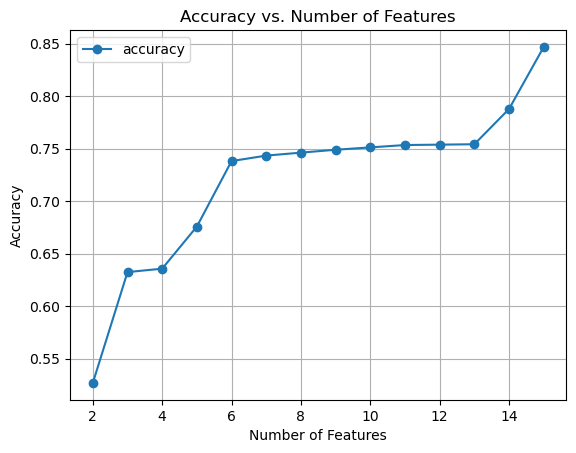

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
import pandas as pd
import matplotlib.pyplot as plt

 
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
 
accuracies = []
pipelines = []

 
for nb_features in range(2, 16):
    
    pipeline = Pipeline([
        ('selection', SelectKBest(k=nb_features)),
        ('model', RandomForestClassifier(random_state=42))
    ])
    
    
    pipeline.fit(X_train, y_train)
    
     
    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    
    accuracies.append({'nb': nb_features, 'accuracy': accuracy})
    pipelines.append({'nb': nb_features, 'pipeline': pipeline})

 
accuracies_df = pd.DataFrame(accuracies)

 
plt.figure(figsize=(10, 6))
accuracies_df.plot.line(x='nb', y='accuracy', marker='o')
plt.title('Accuracy vs. Number of Features')
plt.xlabel('Number of Features')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


In [9]:
 
best_pipeline = pipelines[11]["pipeline"]

 
mask = best_pipeline.named_steps["selection"].get_support()

 
top_features = pd.DataFrame({"feature": cols[mask]})

 
top_features.to_csv(r"O:\Project\NutriScore\Data\top_features.csv" , index=False)
 
top_features


,feature
0,energy
1,saturated_fat
2,sugars
3,group1_Beverages
4,group1_Cereals and potatoes
5,group1_Composite foods
6,group1_Fat and sauces
7,group1_Fish Meat Eggs
8,group1_Fruits and vegetables
9,group1_Milk and dairy products


In [10]:
df_top = df_pca[top_features["feature"]]

df_top

,energy,saturated_fat,sugars,group1_Beverages,group1_Cereals and potatoes,group1_Composite foods,group1_Fat and sauces,group1_Fish Meat Eggs,group1_Fruits and vegetables,group1_Milk and dairy products,group1_Salty snacks,group1_Sugary snacks,group1_unknown
5,0.0,0.0,0.00,False,False,False,False,False,False,False,False,False,True
6,936.0,2.2,22.00,False,False,False,True,False,False,False,False,False,False
9,264.0,0.0,15.50,True,False,False,False,False,False,False,False,False,False
16,916.0,0.5,1.70,False,False,False,False,False,False,False,False,False,True
17,1594.0,15.5,21.90,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2305646,1661.0,0.0,73.00,False,False,False,False,False,False,False,False,False,True
2305648,150.0,0.1,5.00,False,False,False,False,False,False,True,False,False,False
2305650,1552.0,2.5,0.58,False,False,False,False,False,False,False,False,False,True
2305663,2489.0,6.4,0.00,False,False,False,False,False,False,False,False,False,True


In [11]:
df_top["grade"] = y

df_top

C:\Users\sanid\AppData\Local\Temp\ipykernel_15540\1697530630.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top["grade"] = y


,energy,saturated_fat,sugars,group1_Beverages,group1_Cereals and potatoes,group1_Composite foods,group1_Fat and sauces,group1_Fish Meat Eggs,group1_Fruits and vegetables,group1_Milk and dairy products,group1_Salty snacks,group1_Sugary snacks,group1_unknown,grade
5,0.0,0.0,0.00,False,False,False,False,False,False,False,False,False,True,unknown
6,936.0,2.2,22.00,False,False,False,True,False,False,False,False,False,False,d
9,264.0,0.0,15.50,True,False,False,False,False,False,False,False,False,False,d
16,916.0,0.5,1.70,False,False,False,False,False,False,False,False,False,True,unknown
17,1594.0,15.5,21.90,False,False,True,False,False,False,False,False,False,False,d
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2305646,1661.0,0.0,73.00,False,False,False,False,False,False,False,False,False,True,unknown
2305648,150.0,0.1,5.00,False,False,False,False,False,False,True,False,False,False,a
2305650,1552.0,2.5,0.58,False,False,False,False,False,False,False,False,False,True,unknown
2305663,2489.0,6.4,0.00,False,False,False,False,False,False,False,False,False,True,unknown


In [12]:
df_top.to_pickle(r"O:\Project\NutriScore\Data\train.pkl")

### KFold Stratified Dataset

The primary reason for creating a KFold stratified dataset is to ensure that each fold in the cross-validation process maintains a similar distribution of target classes. This is particularly crucial when dealing with imbalanced datasets, where some classes might be underrepresented.

By using stratified folds, you ensure that each fold is a representative sample of the overall dataset. This approach leads to more reliable and unbiased model evaluation.

Without stratified folds, if you directly used your `train.pkl` data, you might end up with biased training and validation sets. This could lead to issues such as overfitting or underfitting. Stratified KFold helps mitigate these issues by maintaining a balanced distribution of classes across all folds.


In [13]:
import numpy as np
 
from sklearn import model_selection

 
folds = pd.read_pickle(r"O:\Project\NutriScore\Data\train.pkl")

 
folds["kfold"] = -1

 
folds = folds.sample(frac=1).reset_index(drop=True)

 
target = np.array(folds.grade)
 
kf = model_selection.StratifiedKFold(n_splits=5)
 
for fold, (_, test_index) in enumerate(kf.split(X=folds, y=target)):
    folds.loc[test_index, "kfold"] = fold
 
folds.to_pickle(r"O:\Project\NutriScore\Data\train_folds.pkl")

 
